Generating 20,000 row glacier dataset...
Performing K-Means Clustering...
Training Models...
Model and Scaler saved successfully!
Model loaded successfully!

--- PERFORMANCE EVALUATION ---
Decision Tree R2 Score: 0.5319
Random Forest R2 Score: 0.6088
Random Forest RMSE: 2.0895


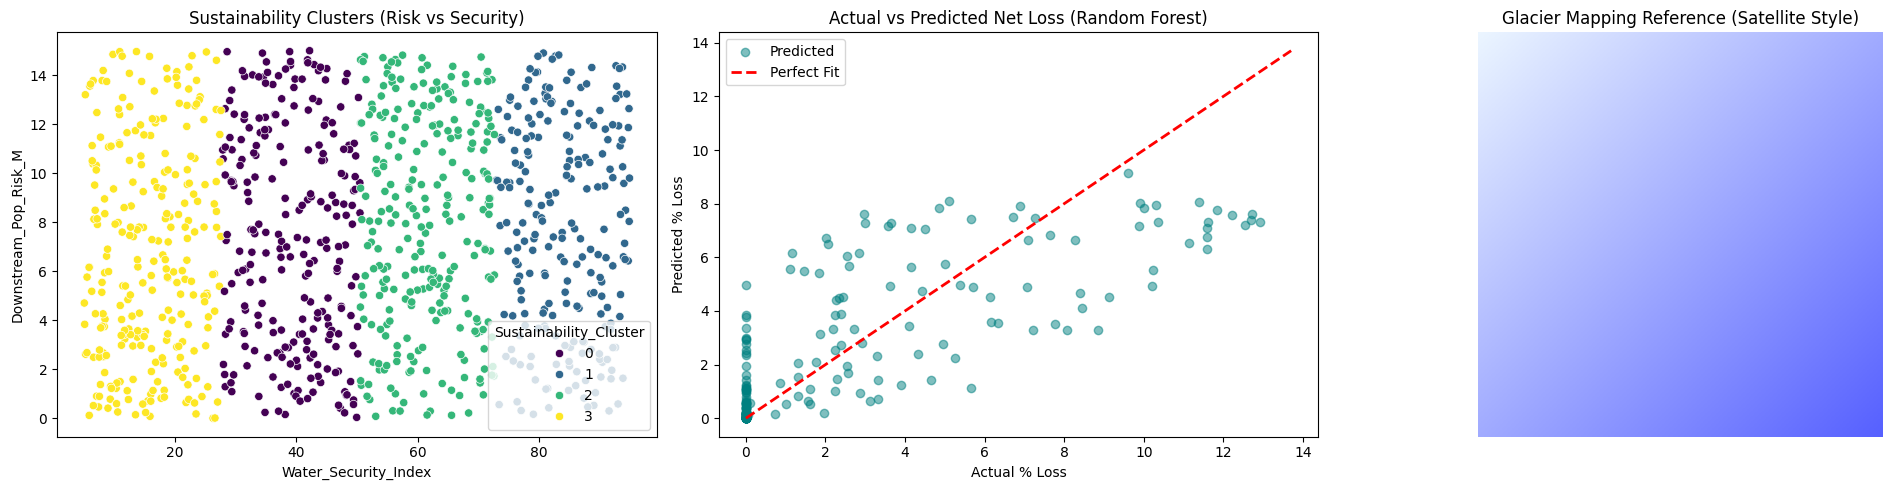


Process Complete. Dataset saved as 'advanced_glacier_sustainability_data.csv'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score


warnings.filterwarnings('ignore')

print("Generating 20,000 row glacier dataset...")
num_rows = 20000
np.random.seed(42)

regions = ['Himalayas', 'Andes', 'Alps', 'Alaska', 'Antarctic', 'Greenland', 'Rockies', 'Caucasus', 'Pamir', 'Urals']
status_options = ['Stable', 'Receding', 'Rapidly Melting', 'Advancing', 'Disappeared']

data = {
    'Glacier_ID': [f"GL-{i:06d}" for i in range(num_rows)],
    'Region': np.random.choice(regions, num_rows),
    'Latitude': np.random.uniform(-90, 90, num_rows).round(5),
    'Longitude': np.random.uniform(-180, 180, num_rows).round(5),
    'Elevation_m': np.random.uniform(200, 8500, num_rows),
    'Area_2000_km2': np.random.uniform(0.5, 1000, num_rows),
    'Annual_Mass_Balance_mwe': np.random.uniform(-4.0, 0.5, num_rows),
    'Avg_Annual_Temp_C': np.random.uniform(-25.0, 8.0, num_rows),
    'Precipitation_mm': np.random.uniform(150, 4500, num_rows),
    'Meltwater_Discharge': np.random.uniform(0.1, 600.0, num_rows),
    'Downstream_Pop_Risk_M': np.random.uniform(0.01, 15.0, num_rows),
    'Water_Security_Index': np.random.uniform(5, 95, num_rows),
    'SDG_13_Compliance': np.random.uniform(1, 10, num_rows),
    'Observation_Status': np.random.choice(status_options, num_rows),
    'Ice_Thickness_m': np.random.uniform(20, 500, num_rows),
    'Debris_Cover_Perc': np.random.uniform(0, 100, num_rows),
    'Albedo_Effect': np.random.uniform(0.1, 0.9, num_rows),
    'Solar_Radiation': np.random.uniform(100, 400, num_rows),
    'Distance_to_City_km': np.random.uniform(5, 500, num_rows)
}

df = pd.DataFrame(data)


df['Net_Loss_Percentage'] = (np.abs(df['Annual_Mass_Balance_mwe']) * 2.5 + (df['Avg_Annual_Temp_C'] * 0.5)).clip(0, 100)


le_region = LabelEncoder()
le_status = LabelEncoder()

df['Region_Encoded'] = le_region.fit_transform(df['Region'])
df['Status_Encoded'] = le_status.fit_transform(df['Observation_Status'])


print("Performing K-Means Clustering...")
cluster_features = ['Water_Security_Index', 'Downstream_Pop_Risk_M']
kmeans = KMeans(n_clusters=4, random_state=42)
df['Sustainability_Cluster'] = kmeans.fit_predict(df[cluster_features])



scaler = StandardScaler()
features_to_scale = ['Elevation_m', 'Area_2000_km2', 'Avg_Annual_Temp_C', 'Precipitation_mm', 'Ice_Thickness_m']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])



X = df[['Region_Encoded', 'Status_Encoded', 'Sustainability_Cluster'] + features_to_scale]
y = df['Net_Loss_Percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Models...")

dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)



import pickle

# Save scaler
with open('scaler.pkl', 'wb') as file1:
    pickle.dump(scaler, file1)

# Save model
with open('model.pkl', 'wb') as file2:
    pickle.dump(rf_reg, file2)

print("Model and Scaler saved successfully!")

# Load model again (testing)
with open('model.pkl', 'rb') as file4:
    m = pickle.load(file4)

print("Model loaded successfully!")




print("\n--- PERFORMANCE EVALUATION ---")
print(f"Decision Tree R2 Score: {r2_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")




fig, axes = plt.subplots(1, 3, figsize=(20, 5))


sns.scatterplot(data=df.sample(1000), x='Water_Security_Index', y='Downstream_Pop_Risk_M',
                hue='Sustainability_Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('Sustainability Clusters (Risk vs Security)')


axes[1].scatter(y_test[:200], y_pred_rf[:200], alpha=0.5, color='teal', label='Predicted')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[1].set_title('Actual vs Predicted Net Loss (Random Forest)')
axes[1].set_xlabel('Actual % Loss')
axes[1].set_ylabel('Predicted % Loss')
axes[1].legend()

glacier_img = np.zeros((300, 300, 3), dtype=np.uint8)
for i in range(300):
    for j in range(300):
        base_val = 255 - int((i + j) / 4)
        r = max(0, min(255, base_val - 20))
        g = max(0, min(255, base_val - 10))
        b = 255 # Maintains blue intensity
        glacier_img[i, j] = [r, g, b]
axes[2].imshow(glacier_img)
axes[2].axis('off')
axes[2].set_title('Glacier Mapping Reference (Satellite Style)')

plt.tight_layout()
plt.show()


df.to_csv('advanced_glacier_sustainability_data.csv', index=False)
print("\nProcess Complete. Dataset saved as 'advanced_glacier_sustainability_data.csv'.")